Loading coil images from dataset/imgs.pt...
Loading data from /home/wogur110/Stanford/EE274/project_JH/EE274-dynamic-coil-compression/dataset/imgs.pt...
Coil images shape: (64, 294, 294), dtype: complex64
Loading sensitivity maps from /home/wogur110/Stanford/EE274/project_JH/EE274-dynamic-coil-compression/results/refer0/sensitivity_maps.pt...
Sensitivity maps shape: (64, 294, 294), dtype: complex64


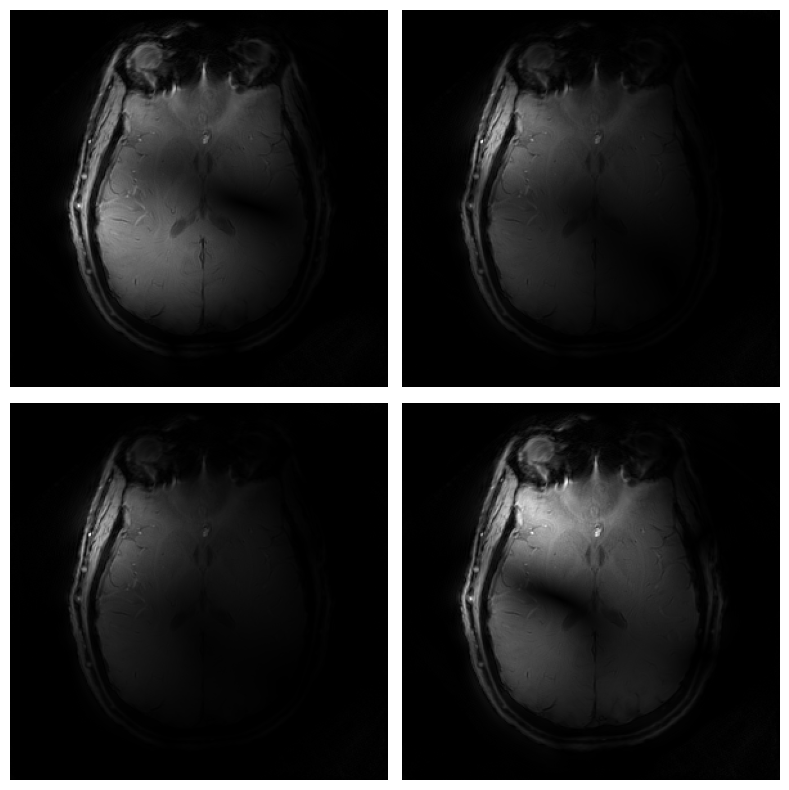

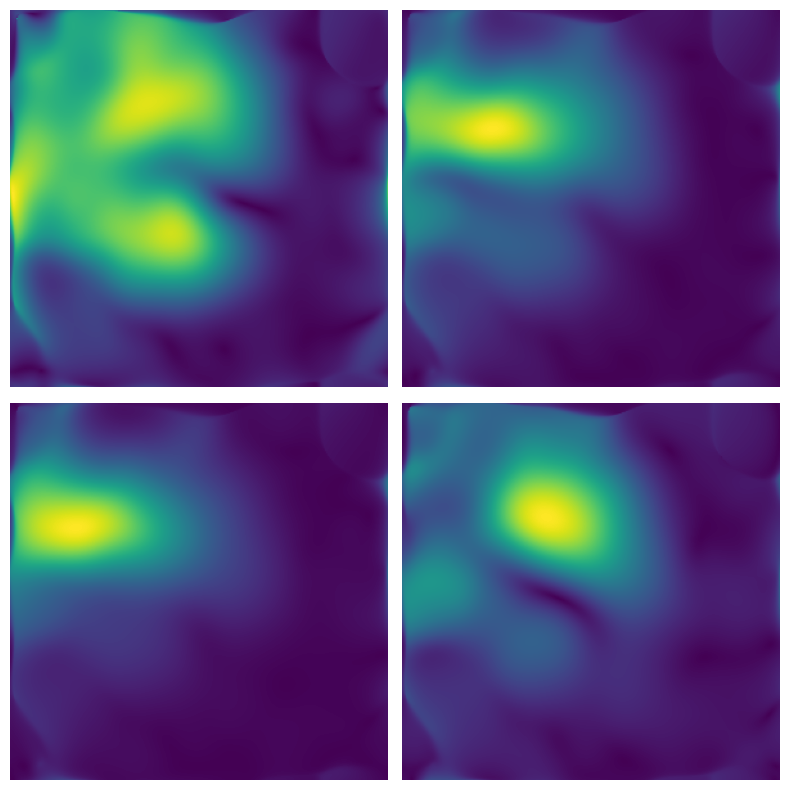

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sys

# Add parent directory to path for imports
script_dir = os.getcwd()
project_root = os.path.dirname(script_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.mri_utils import load_imgs

# Load actual coil images from dataset/imgs.pt
print("Loading coil images from dataset/imgs.pt...")
coil_imgs = load_imgs()
print(f"Coil images shape: {coil_imgs.shape}, dtype: {coil_imgs.dtype}")

# Load sensitivity maps from results/refer0/sensitivity_maps.pt
maps_path = os.path.join(project_root, "results", "refer0", "sensitivity_maps.pt")
print(f"Loading sensitivity maps from {maps_path}...")
sens_maps = torch.load(maps_path, map_location='cpu')
if isinstance(sens_maps, torch.Tensor):
    sens_maps = sens_maps.numpy()
print(f"Sensitivity maps shape: {sens_maps.shape}, dtype: {sens_maps.dtype}")

# Select first 4 coils for visualization
num_coils_to_plot = 4
coil_imgs_plot = coil_imgs[:num_coils_to_plot]
sens_maps_plot = sens_maps[:num_coils_to_plot]

# Plot coil images (magnitude) with proper orientation
fig1, axes1 = plt.subplots(2, 2, figsize=(8, 8))
axes1 = axes1.flatten()
for i in range(num_coils_to_plot):
    ax = axes1[i]
    # Transpose and flip for correct orientation (matching other scripts)
    img_display = np.flipud(np.abs(coil_imgs_plot[i]).T)
    ax.imshow(img_display, cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Plot sensitivity maps (magnitude) with proper orientation
fig2, axes2 = plt.subplots(2, 2, figsize=(8, 8))
axes2 = axes2.flatten()
for i in range(num_coils_to_plot):
    ax = axes2[i]
    # Transpose and flip for correct orientation (matching other scripts)
    sens_display = np.flipud(np.abs(sens_maps_plot[i]).T)
    ax.imshow(sens_display, cmap='viridis')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Combine coil images using sensitivity maps
from utils.mri_utils import normalize_complex_image

print("Combining coil images using sensitivity maps...")
weights = np.sum(np.abs(sens_maps)**2, axis=0)
weights = weights + 1e-16
combined_img = np.sum(coil_imgs * np.conj(sens_maps), axis=0) / weights
combined_img = normalize_complex_image(combined_img)
print(f"Combined image shape: {combined_img.shape}, dtype: {combined_img.dtype}")

# Plot combined image
plt.figure(figsize=(6, 6))
combined_display = np.flipud(np.abs(combined_img).T)
plt.imshow(combined_display, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


Loading reference image from /home/wogur110/Stanford/EE274/project_JH/EE274-dynamic-coil-compression/results/refer0/ref_image.pt...
Reference image shape: (294, 294), dtype: complex64


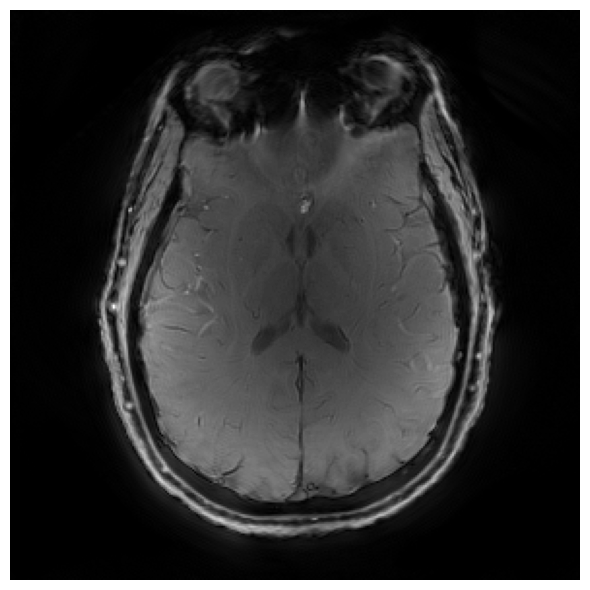

In [6]:
import torch

# Path to ref_image.pt
ref_img_path = os.path.join(project_root, "results", "refer0", "ref_image.pt")
print(f"Loading reference image from {ref_img_path}...")

try:
    ref_img = torch.load(ref_img_path, map_location='cpu')
    if isinstance(ref_img, torch.Tensor):
        ref_img = ref_img.numpy()
    print(f"Reference image shape: {ref_img.shape}, dtype: {ref_img.dtype}")
except Exception as e:
    print(f"Failed to load reference image: {e}")
    ref_img = None

if ref_img is not None:
    # Plot reference image (magnitude)
    plt.figure(figsize=(6, 6))
    img_display = np.flipud(np.abs(ref_img).T)
    plt.imshow(img_display, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


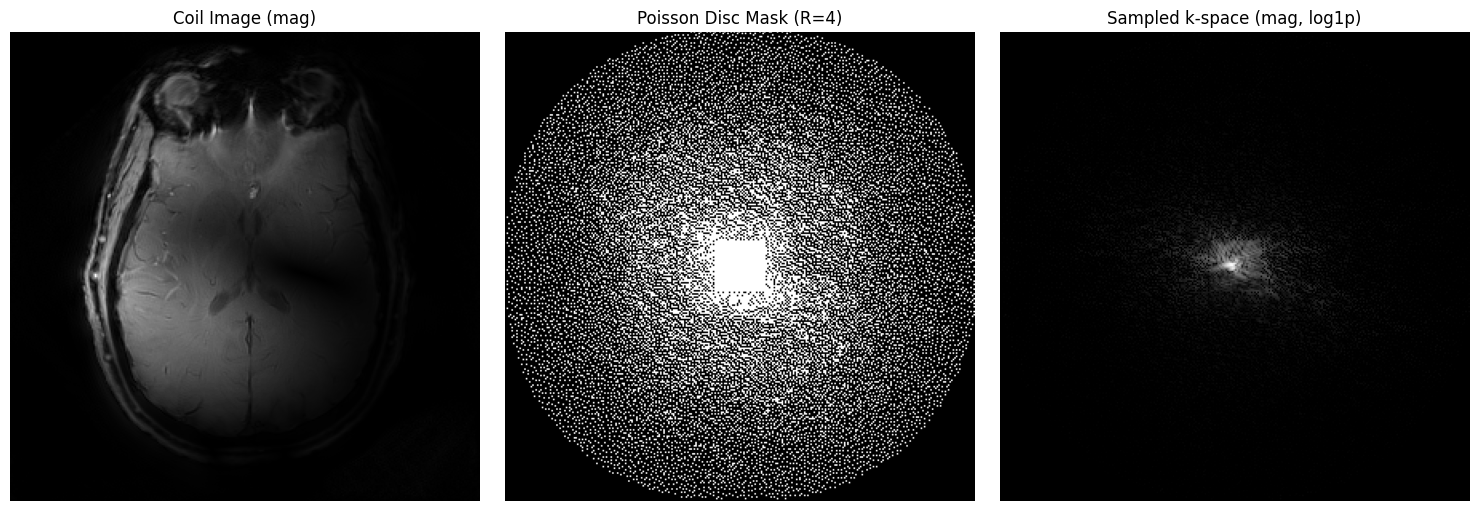

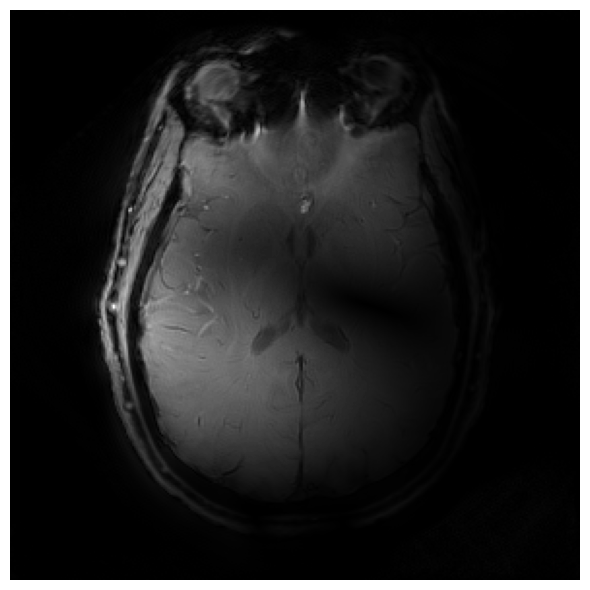

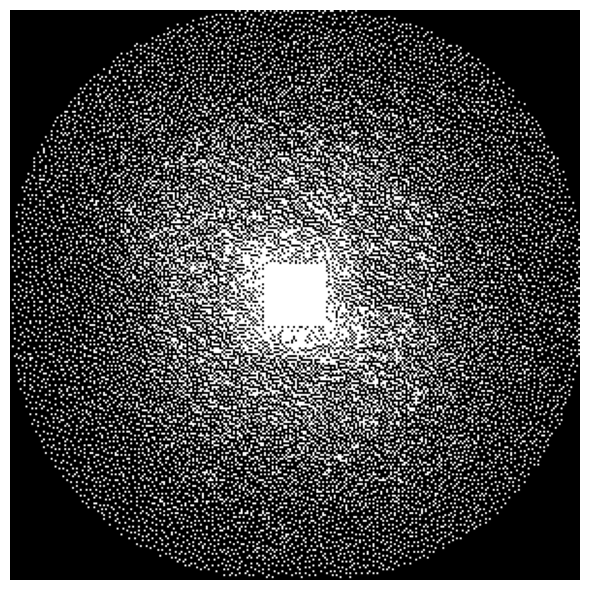

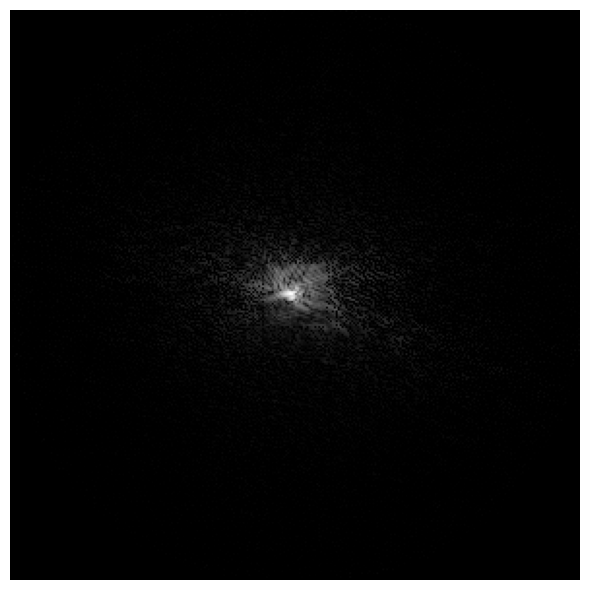

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Assume we have coil_imgs already loaded (from previous context)
# Let's pick the first coil image
coil_img = coil_imgs[0]

# Generate a Poisson disc sampling pattern with R=4 and calibration region 32x32
from dynamic_coil_compression_waterfilling import get_poisson_mask
N, H, W = coil_imgs.shape
accel = 4
calib = (32, 32)
mask = get_poisson_mask((1, H, W), accel=accel, calib=calib, seed=0)
mask = mask[0]  # shape (H, W)

# FFT2 of the coil image
import scipy.fft as sp
kspace = sp.fft2(coil_img)
kspace_shifted = sp.fftshift(kspace)

# Apply the sampling mask in k-space
kspace_sampled = kspace_shifted * mask

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Coil image (magnitude)
img_display = np.flipud(np.abs(coil_img).T)
axs[0].imshow(img_display, cmap='gray')
axs[0].set_title('Coil Image (mag)')
axs[0].axis('off')

# Poisson disc mask
axs[1].imshow(np.flipud(mask.T), cmap='gray')
axs[1].set_title('Poisson Disc Mask (R=4)')
axs[1].axis('off')

# k-space magnitude with sampling pattern
kspace_sampled_display = np.flipud(np.log1p(np.abs(kspace_sampled)).T)
axs[2].imshow(kspace_sampled_display, cmap='gray')
axs[2].set_title('Sampled k-space (mag, log1p)')
axs[2].axis('off')

plt.tight_layout()
# Plot each image in separate figures

# Coil image (magnitude)
plt.figure(figsize=(6, 6))
plt.imshow(img_display, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Poisson disc mask
plt.figure(figsize=(6, 6))
plt.imshow(np.flipud(mask.T), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# k-space magnitude with sampling pattern
plt.figure(figsize=(6, 6))
plt.imshow(kspace_sampled_display, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


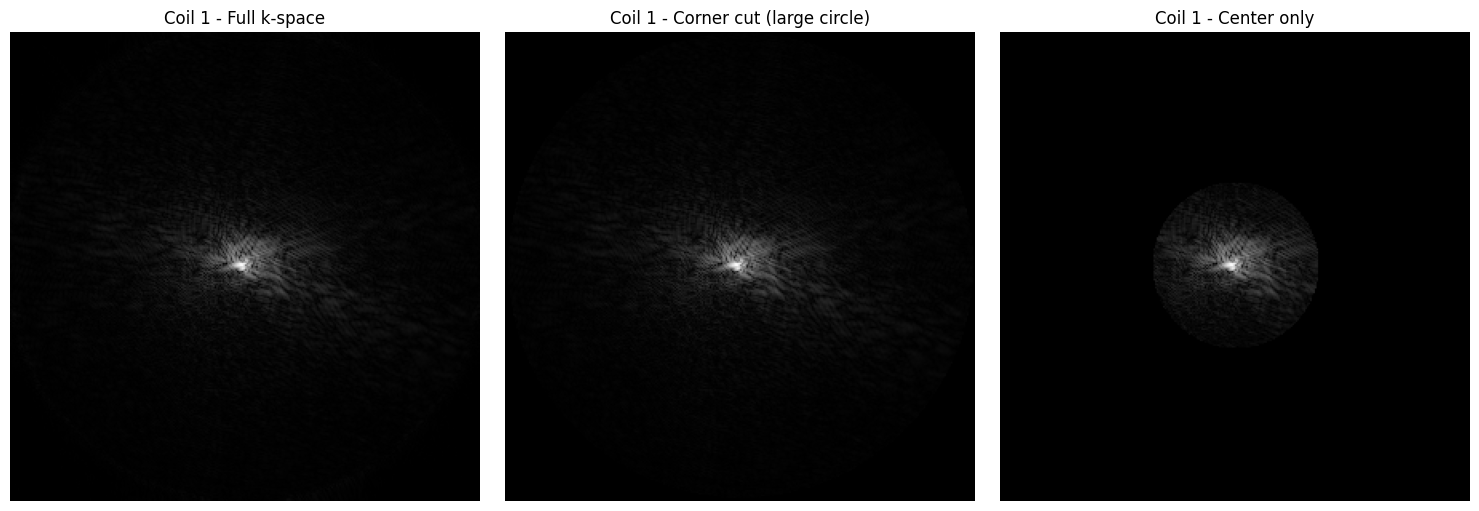

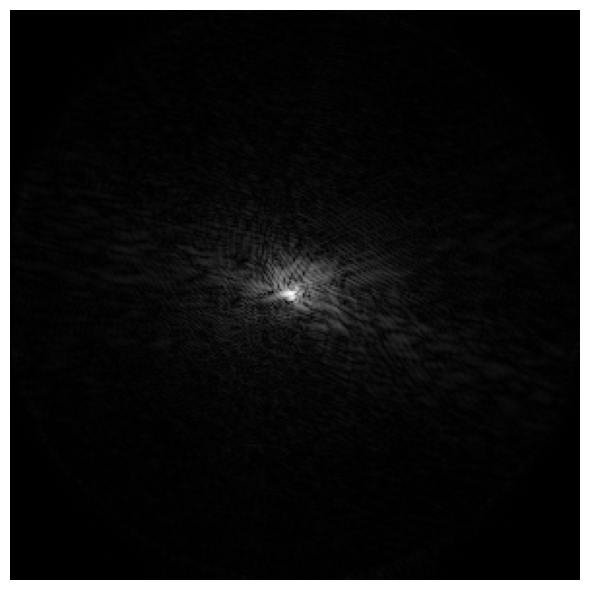

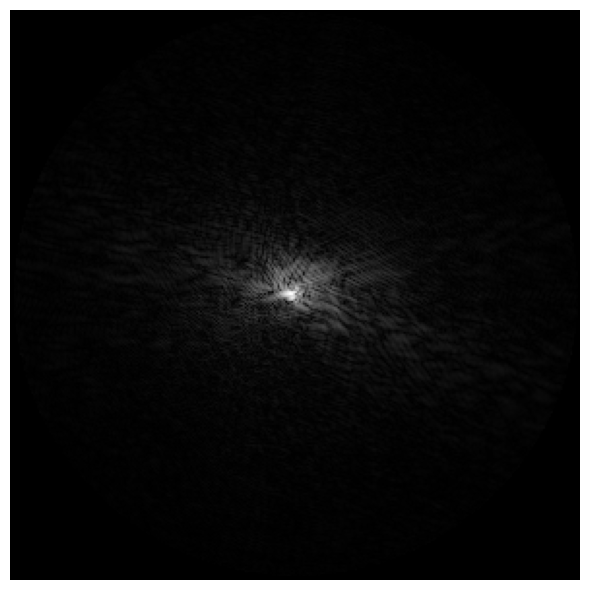

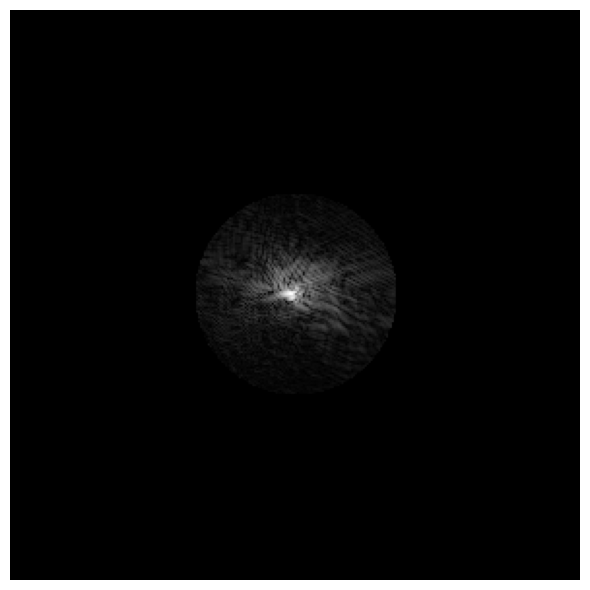

IndexError: index 4 is out of bounds for axis 0 with size 1

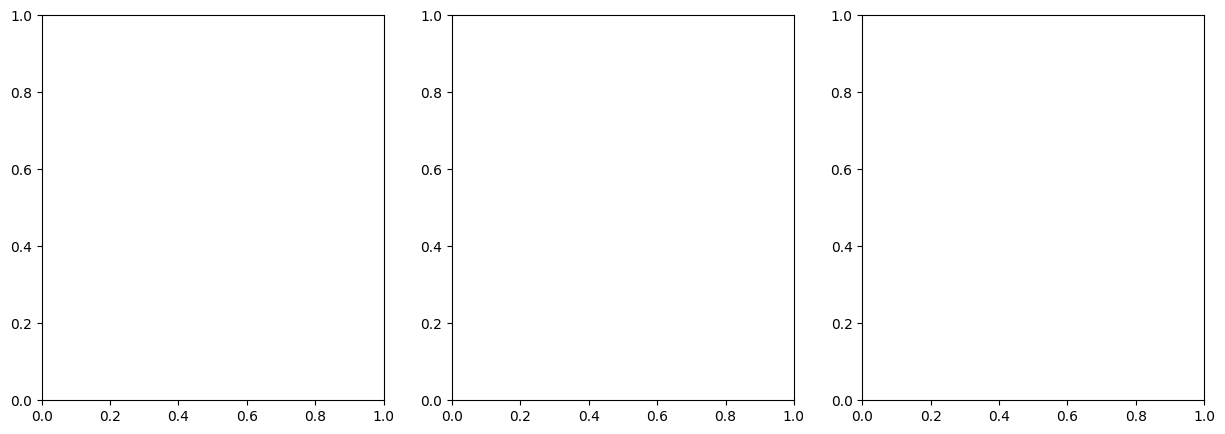

In [15]:
# Calculate coil k-space for each coil (by FFT of coil_img along spatial dims)
# Assumes coil_img is the image for a single coil (H, W) or all coils (N_coils, H, W)
# If coil_img is for a single coil, add batch/coils axis
import numpy as np

if coil_img.ndim == 2:
    coil_img_for_kspace = coil_img[None, ...]
else:
    coil_img_for_kspace = coil_img

coil_kspace = np.fft.fftshift(
    np.fft.fft2(coil_img_for_kspace, axes=(-2, -1)),
    axes=(-2, -1)
)
# Visualization of full k-space, corners cut, and center for coils 1, 5, 10

import matplotlib.pyplot as plt

# Choose coil indices. Adjust if you have fewer than 10 coils!
coil_indices = [0, 4, 9]  # coil 1, 5, 10 (Python 0-based indexing)

# Extract shape info
N_coils, H, W = coil_kspace.shape

def circular_mask(H, W, radius_ratio):
    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    Y, X = np.meshgrid(y, x, indexing='ij')
    R = np.sqrt(Y**2 + X**2)
    max_r = np.sqrt(cy**2 + cx**2)
    R_norm = R / max_r
    return R_norm <= radius_ratio

# Masks
mask_large = circular_mask(H, W, radius_ratio=0.7)
mask_center = circular_mask(H, W, radius_ratio=0.25)

for idx in coil_indices:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # Full k-space
    mag_full = np.log1p(np.abs(coil_kspace[idx]))
    axes[0].imshow(np.flipud(mag_full.T), cmap='gray')
    axes[0].set_title(f'Coil {idx+1} - Full k-space')

    # Corners cut (large circle)
    mag_largecut = mag_full * mask_large
    axes[1].imshow(np.flipud(mag_largecut.T), cmap='gray')
    axes[1].set_title(f'Coil {idx+1} - Corner cut (large circle)')

    # Only center (small circle)
    mag_center = mag_full * mask_center
    axes[2].imshow(np.flipud(mag_center.T), cmap='gray')
    axes[2].set_title(f'Coil {idx+1} - Center only')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Plot each view (full k-space, corners cut, center) in separate figures for clarity

    fig_full, ax_full = plt.subplots(figsize=(6, 6))
    ax_full.imshow(np.flipud(mag_full.T), cmap='gray')
    ax_full.axis('off')
    plt.tight_layout()
    plt.show()

    fig_largecut, ax_largecut = plt.subplots(figsize=(6, 6))
    ax_largecut.imshow(np.flipud(mag_largecut.T), cmap='gray')
    ax_largecut.axis('off')
    plt.tight_layout()
    plt.show()

    fig_center, ax_center = plt.subplots(figsize=(6, 6))
    ax_center.imshow(np.flipud(mag_center.T), cmap='gray')
    ax_center.axis('off')
    plt.tight_layout()
    plt.show()




Showing rec_K48_cut1.00.pt:


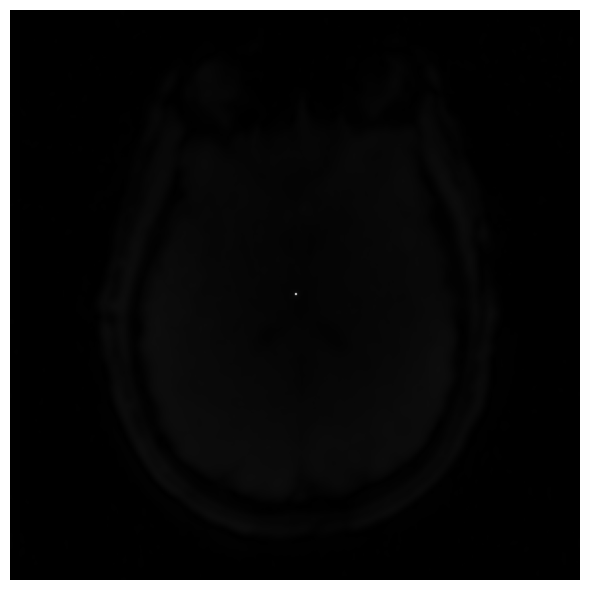

Showing rec_img_rank48.pt:


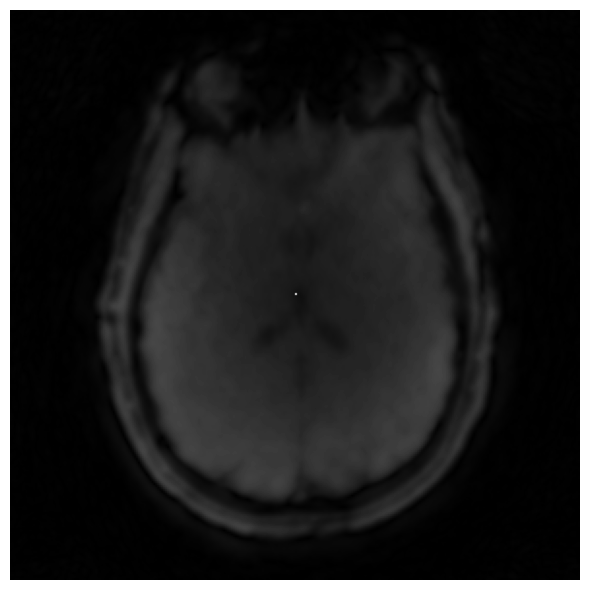

Showing rec_img_q80.pt:


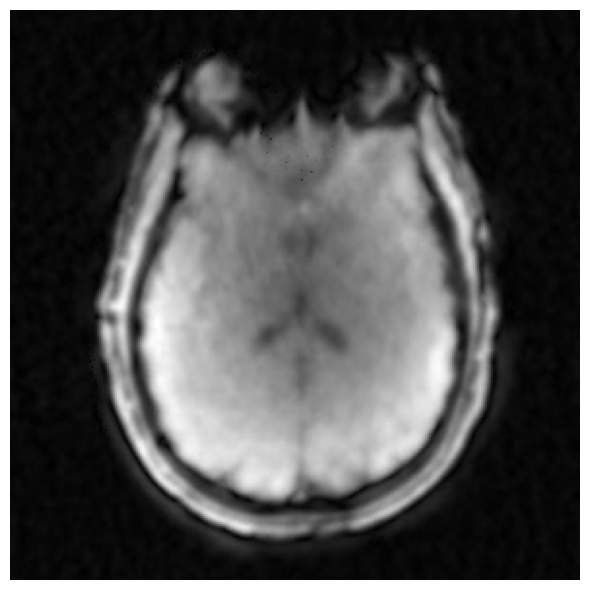

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from utils.mri_utils import normalize_complex_image

# Load sensitivity maps (needed for combining multi-coil images)
maps_path = os.path.join(project_root, "results", "refer0", "sensitivity_maps.pt")
sens_maps = torch.load(maps_path, map_location='cpu')
if isinstance(sens_maps, torch.Tensor):
    sens_maps = sens_maps.numpy()

def load_and_display_image(pt_path, sens_maps=None):
    # Load image
    img_tensor = torch.load(pt_path)
    img = img_tensor.numpy() if hasattr(img_tensor, 'numpy') else img_tensor
    # Reduce to image if there is a singleton dimension (e.g. [1, H, W] or [H, W]), assume complex if last dim=2
    img = np.squeeze(img)
    if img.ndim == 3 and img.shape[0] == 1:
        img = img[0]
    # If it's complex-valued with separate real/imag, make it complex
    if np.isrealobj(img) and img.shape[-1] == 2:
        img = img[...,0] + 1j*img[...,1]
    
    # Check if image is multi-coil (shape like (N_coils, H, W) or (H, W, N_coils))
    if img.ndim == 3:
        # Assume first dimension is coils if it's small (< 100), otherwise last dimension
        if img.shape[0] < 100:
            # Shape is (N_coils, H, W)
            coil_imgs_rec = img
        else:
            # Shape is (H, W, N_coils) - transpose to (N_coils, H, W)
            coil_imgs_rec = np.transpose(img, (2, 0, 1))
        
        # Combine using sensitivity maps if available and number of coils matches
        # For compressed coils (virtual coils), use sum-of-squares instead
        N_coils = coil_imgs_rec.shape[0]
        if sens_maps is not None and N_coils == sens_maps.shape[0]:
            # Original coils - use sensitivity-weighted combination
            weights = np.sum(np.abs(sens_maps)**2, axis=0)
            weights = weights + 1e-16
            combined_img = np.sum(coil_imgs_rec * np.conj(sens_maps), axis=0) / weights
            combined_img = normalize_complex_image(combined_img)
            img = combined_img
        else:
            # Compressed/virtual coils - use sum-of-squares combination
            combined_img = np.sqrt(np.sum(np.abs(coil_imgs_rec)**2, axis=0))
            combined_img = normalize_complex_image(combined_img)
            img = combined_img
    
    # Take magnitude
    mag = np.abs(img)
    # Normalize magnitude for proper visualization
    mag = mag / np.max(mag)
    # Transpose and flip for correct orientation (matching other scripts)
    img_display = np.flipud(mag.T)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_display, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

paths = [
    '/home/wogur110/Stanford/EE274/project_JH/EE274-dynamic-coil-compression/results/dynamic_coil_compression_waterfilling/R16/rec_K48_cut1.00.pt',
    '/home/wogur110/Stanford/EE274/project_JH/EE274-dynamic-coil-compression/results/uniform_coil_compression/R16/rec_img_rank48.pt',
    '/home/wogur110/Stanford/EE274/project_JH/EE274-dynamic-coil-compression/results/refer1a_jpeg_compression/R16/rec_img_q80.pt'
]

for pt_path in paths:
    print(f"Showing {os.path.basename(pt_path)}:")
    load_and_display_image(pt_path, sens_maps=sens_maps)
